## 一、RFM模型核心原理
### 1. 定义与起源
RFM（Recency, Frequency, Monetary）是经典用户价值分层模型，1966年由Paul Zipkin提出，通过**最近消费时间、消费频率、消费金额**三个核心指标，将用户细分为不同群体，评估其活跃度、忠诚度和贡献度。

### 2. 指标含义（通用/互联网场景）
| 指标 | 通用商品 | 互联网产品 | 含义 |
|------|----------|------------|------|
| **R (Recency)** | 最近一次消费 | 最近一次登录 | 时间越近，用户越活跃 |
| **F (Frequency)** | 消费频率 | 登录频率 | 次数越多，用户越忠诚 |
| **M (Monetary)** | 消费金额 | 在线时长 | 数值越高，用户价值越高 |

### 3. 打分方式
- **行业规则法**：适合标准统一行业（如酒店/航空），直接按业务规则划分等级。
- **百分位法**：将数据按20%/40%/60%/80%分位数划分为1~5分，分值越高价值越高（R值相反：时间越近得分越高）。
- **均值转换法**：将1~5分按均值转换为0/1，0代表低价值，1代表高价值。

### 4. 用户8类分层
| R | F | M | 用户分类 | 含义 | 营销策略 |
|---|---|---|----------|------|----------|
| 1 | 1 | 1 | 重要价值客户 | 最近购买、高频、高消费 | 发展：专属优惠、个性化服务 |
| 1 | 1 | 0 | 重要潜力客户 | 最近购买、高频、低消费 | 发展：积分奖励、提升客单价 |
| 1 | 0 | 1 | 重要深耕客户 | 最近购买、低频、高消费 | 发展：个性化推荐、唤醒复购 |
| 1 | 0 | 0 | 新客户 | 最近购买、低频、低消费 | 发展：新人礼包、引导首单 |
| 0 | 1 | 1 | 重要唤回客户 | 最近未购、高频、高消费 | 挽留：关怀回访、专属折扣 |
| 0 | 1 | 0 | 一般客户 | 最近未购、高频、低消费 | 发展：积分刺激、提升消费 |
| 0 | 0 | 1 | 重要挽回客户 | 最近未购、低频、高消费 | 挽留：大额优惠、重新激活 |
| 0 | 0 | 0 | 流失客户 | 最近未购、低频、低消费 | 挽留：召回礼包、调研唤醒 |



## 二、Python实现RFM模型

### 1. 数据读取与基础信息

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rc('font',**{'family':'Microsoft YaHei,SimHei'})
df = pd.read_csv('美妆个护平台会员与非会员消费记录.csv')
df.sample(5)

,会员卡号,消费产生的时间,商品编码,销售数量,商品售价,消费金额,商品名称,此次消费的会员积分,单据号,出生日期,性别,登记时间,年龄,是否为会员
718959,8db94d6b,2017-08-25 12:36:18.736,d72de91e,1,50600.0,50600.0,欧米伽.,10120.0,4369,NaN,NaN,NaN,NaN,0
307358,2f32c55a,2016-05-15 15:15:14.156,fba32e79,1,2691.0,2691.0,迪桑娜女鞋A.,2691.0,7cd8,1981.0,0.0,2008-12-11 00:00:00.000,40.0,1
527459,57d21a60,2017-01-22 16:39:28.593,b264e578,1,920.0,920.0,Juicy Couyure F件,920.0,d399,NaN,NaN,NaN,NaN,0
777816,b7257df8,2017-10-03 13:42:18.220,94c3a5b8,1,350.0,350.0,香奈儿臻魅/纤长/炫密睫毛膏滋养底,350.0,d9f5,1983.0,0.0,2011-10-04 00:00:00.000,38.0,1
550450,68446cbe,2017-02-18 15:49:05.110,f09c9303,1,225.0,38.1,兰芝化妆品正价瓶,38.0,5072,1971.0,0.0,2016-12-04 00:00:00.000,50.0,1


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876046 entries, 0 to 876045
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   会员卡号       876046 non-null  object 
 1   消费产生的时间    876046 non-null  object 
 2   商品编码       876046 non-null  object 
 3   销售数量       876046 non-null  int64  
 4   商品售价       876046 non-null  float64
 5   消费金额       876046 non-null  float64
 6   商品名称       876046 non-null  object 
 7   此次消费的会员积分  876046 non-null  float64
 8   单据号        876046 non-null  object 
 9   出生日期       474446 non-null  float64
 10  性别         474446 non-null  float64
 11  登记时间       474446 non-null  object 
 12  年龄         474446 non-null  float64
 13  是否为会员      876046 non-null  int64  
dtypes: float64(6), int64(2), object(6)
memory usage: 93.6+ MB



### 2. 计算R/F/M指标
#### (1) 计算R值（最近一次消费距今天数）

In [36]:
r = df.groupby('会员卡号')['消费产生的时间'].max().reset_index(name = '最近一次消费的时间')
r

,会员卡号,最近一次消费的时间
0,000186fa,2017-09-24 12:47:35.986
1,000234ad,2017-11-01 16:43:04.126
2,0002adb8,2016-06-30 18:17:23.376
3,000339f1,2017-12-16 16:02:36.610
4,0003a4e7,2015-02-12 20:23:07.626
...,...,...
89327,fffbcb4f,2015-04-18 15:03:20.203
89328,fffbd0ce,2016-12-05 14:19:46.236
89329,fffbfb51,2015-05-07 21:30:27.783
89330,fffc9664,2015-05-08 20:15:47.830


In [37]:
r['R'] = (pd.to_datetime('2018-1-4')-pd.to_datetime(r['最近一次消费的时间'])).dt.days
r.head()

,会员卡号,最近一次消费的时间,R
0,000186fa,2017-09-24 12:47:35.986,101
1,000234ad,2017-11-01 16:43:04.126,63
2,0002adb8,2016-06-30 18:17:23.376,552
3,000339f1,2017-12-16 16:02:36.610,18
4,0003a4e7,2015-02-12 20:23:07.626,1056


#### (2)计算F值(消费频率）

In [38]:
f = df.groupby(['会员卡号','单据号']).size().reset_index().groupby('会员卡号').size().reset_index(name = '消费次数')
f['F'] = f['消费次数']
f.head()

,会员卡号,消费次数,F
0,000186fa,4,4
1,000234ad,7,7
2,0002adb8,2,2
3,000339f1,8,8
4,0003a4e7,2,2


#### (3)计算M值（消费金额)

In [39]:
sum_m = df.groupby('会员卡号')['消费金额'].sum().reset_index(name='消费总金额')
data = pd.merge(left=f,right=sum_m,on='会员卡号')
data['M'] = round(data['消费总金额']/data['F'])
data.head()

,会员卡号,消费次数,F,消费总金额,M
0,000186fa,4,4,11880.7,2970.0
1,000234ad,7,7,12850.0,1836.0
2,0002adb8,2,2,7136.0,3568.0
3,000339f1,8,8,6340.8,793.0
4,0003a4e7,2,2,1219.0,610.0


In [40]:
rfm = pd.merge(r,data,on='会员卡号')
rfm = rfm[['会员卡号','R','F','M']]
rfm.head()

,会员卡号,R,F,M
0,000186fa,101,4,2970.0
1,000234ad,63,7,1836.0
2,0002adb8,552,2,3568.0
3,000339f1,18,8,793.0
4,0003a4e7,1056,2,610.0


### 3. 维度打分（百分位法）

In [41]:
quantiles = [0.2, 0.4, 0.6, 0.8]
rfm[['R', 'F', 'M']].quantile(quantiles)

,R,F,M
0.2,77.0,1.0,698.2
0.4,233.0,2.0,1305.0
0.6,433.0,3.0,2144.0
0.8,890.0,6.0,3730.0


In [42]:
rfm['R_score'] = pd.cut(rfm['R'],bins = [0,77,233,433,890,1000000],labels=[5,4,3,2,1]).astype(float)
rfm['F_score'] = pd.cut(rfm['F'],bins = [0,1,2,3,6,1000000],labels=[1,2,3,4,5]).astype(float)
rfm['M_score'] = pd.cut(rfm['M'],bins = [0,698.2,1305,2144,3730,1000000],labels=[1,2,3,4,5]).astype(float)

rfm.head()

,会员卡号,R,F,M,R_score,F_score,M_score
0,000186fa,101,4,2970.0,4.0,4.0,4.0
1,000234ad,63,7,1836.0,5.0,5.0,3.0
2,0002adb8,552,2,3568.0,2.0,2.0,4.0
3,000339f1,18,8,793.0,5.0,5.0,2.0
4,0003a4e7,1056,2,610.0,1.0,2.0,1.0


### 4. 客户分层
#### (1) 转换为0/1高/低价值

In [43]:
rfm['R是否大于均值'] = (rfm['R_score']>rfm['R_score'].mean())*1
rfm['F是否大于均值'] = (rfm['F_score']>rfm['F_score'].mean())*1
rfm['M是否大于均值'] = (rfm['M_score']>rfm['M_score'].mean())*1
rfm.head()

,会员卡号,R,F,M,R_score,F_score,M_score,R是否大于均值,F是否大于均值,M是否大于均值
0,000186fa,101,4,2970.0,4.0,4.0,4.0,1,1,1
1,000234ad,63,7,1836.0,5.0,5.0,3.0,1,1,0
2,0002adb8,552,2,3568.0,2.0,2.0,4.0,0,0,1
3,000339f1,18,8,793.0,5.0,5.0,2.0,1,1,0
4,0003a4e7,1056,2,610.0,1.0,2.0,1.0,0,0,0


In [44]:
rfm['总分'] = (rfm['R是否大于均值']*100+rfm['F是否大于均值']*10+rfm['M是否大于均值']*1)

In [45]:
rfm['总分']

0        111
1        110
2          1
3        110
4          0
        ... 
89327      0
89328    111
89329      0
89330      0
89331      0
Name: 总分, Length: 89332, dtype: int64

表17-11 用户分类对应的总分
 R价值类别  F价值类别  M价值类别   用户分类  总分
     1      1      1 重要价值客户 111
     1      1      0 重要潜力客户 110
     1      0      1 重要深耕客户 101
     1      0      0    新客户 100
     0      1      1 重要唤回客户  11
     0      1      0   一般客户  10
     0      0      1 重要挽回客户   1
     0      0      0   流失客户   0


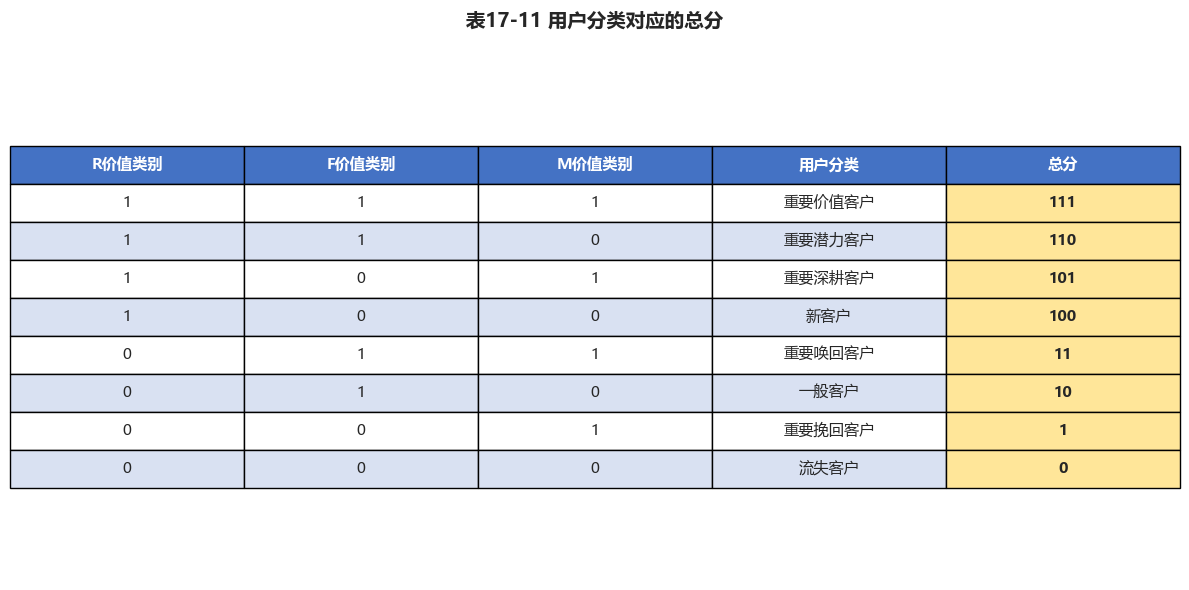

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'R价值类别': [1, 1, 1, 1, 0, 0, 0, 0],
    'F价值类别': [1, 1, 0, 0, 1, 1, 0, 0],
    'M价值类别': [1, 0, 1, 0, 1, 0, 1, 0],
    '用户分类': ['重要价值客户', '重要潜力客户', '重要深耕客户', '新客户',
               '重要唤回客户', '一般客户', '重要挽回客户', '流失客户'],
    '总分': [111, 110, 101, 100, 11, 10, 1, 0]
}

df = pd.DataFrame(data)

# 显示表格
print("表17-11 用户分类对应的总分")
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)

# 创建可视化表格图
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# 设置表格样式
table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#4472C4']*5)

# 设置表格样式
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# 设置表头样式
for i in range(5):
    table[(0, i)].set_text_props(color='white', fontweight='bold')
    table[(0, i)].set_facecolor('#4472C4')

# 设置数据行样式（交替颜色）
colors = ['#D9E1F2', '#FFFFFF']
for i in range(1, 9):
    for j in range(5):
        table[(i, j)].set_facecolor(colors[i % 2])

# 高亮"总分"列
for i in range(1, 9):
    table[(i, 4)].set_facecolor('#FFE699')
    table[(i, 4)].set_text_props(fontweight='bold')

plt.title('表17-11 用户分类对应的总分', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

plt.show()


使用map函数将总分与对应的用户分类标签一一对应

In [46]:
client_labels = {
    111:'重要价值客户',
    110:'重要潜力客户',
    101:'重要深耕客户',
    100:'新客户',
    11:'重要唤回客户',
    10:'一般客户',
    1:'重要挽回客户',
    0:'流失客户'
}
rfm['客户类型'] = rfm['总分'].map(client_labels)
rfm.head()

,会员卡号,R,F,M,R_score,F_score,M_score,R是否大于均值,F是否大于均值,M是否大于均值,总分,客户类型
0,000186fa,101,4,2970.0,4.0,4.0,4.0,1,1,1,111,重要价值客户
1,000234ad,63,7,1836.0,5.0,5.0,3.0,1,1,0,110,重要潜力客户
2,0002adb8,552,2,3568.0,2.0,2.0,4.0,0,0,1,1,重要挽回客户
3,000339f1,18,8,793.0,5.0,5.0,2.0,1,1,0,110,重要潜力客户
4,0003a4e7,1056,2,610.0,1.0,2.0,1.0,0,0,0,0,流失客户



## 三、进阶分析：F/M矩阵与用户细分
### 1. F/M矩阵分析

In [47]:
# 列联表分析
pd.crosstab(index=rfm['M_score'],columns= rfm['F_score'],normalize='columns').applymap(lambda x:str(round(x*100))+'%')


C:\Users\24677\AppData\Local\Temp\ipykernel_38676\1089957689.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pd.crosstab(index=rfm['M_score'],columns= rfm['F_score'],normalize='columns').applymap(lambda x:str(round(x*100))+'%')


F_score,1.0,2.0,3.0,4.0,5.0
M_score,,,,,
1.0,31%,21%,16%,10%,4%
2.0,19%,23%,23%,22%,16%
3.0,17%,20%,22%,24%,23%
4.0,15%,19%,21%,23%,29%
5.0,18%,17%,18%,20%,29%



- **解读**：
  - 低F低M：价格敏感用户（仅在促销时购买）
  - 低F高M：囤货用户（低频高客单，集中在促销节点）
  - 高F低M：忠诚但价格敏感用户（多在有优惠时消费）

### 2.识别对价值敏感的用户

In [48]:
# F = 1的会员卡号列表
f_1_index = rfm.query('F==1')['会员卡号'].values

# F = 1的用户群
f1_group = df[df['会员卡号'].isin(f_1_index)]
# F = 1且商品售价大于消费金额的用户群，即关注新客优惠的人群
f1_extreme = f1_group.query('商品售价>消费金额')
print(f'F = 1的用户数为:{f1_group["会员卡号"].unique()}')
print(f'F = 1且关注新客优惠的用户数为:{f1_extreme["会员卡号"].unique()}')
f1_extreme.sample(10)

F = 1的用户数为:['8527d4d0' '9065a184' 'd0e078ce' ... '2d9b0d8a' 'dd018e94' '69de49e9']
F = 1且关注新客优惠的用户数为:['8527d4d0' '8b43e423' '3115bbfc' ... '349e7d8c' 'a5bf2305' 'de6bab40']


,会员卡号,消费产生的时间,商品编码,销售数量,商品售价,消费金额,商品名称,此次消费的会员积分,单据号,出生日期,性别,登记时间,年龄,是否为会员
680876,a5f024fa,2017-07-06 15:21:35.470,eff269d7,1,420.0,411.60,科颜氏金盏花舒缓保湿面膜瓶,0.0,028f,1980.0,0.0,2017-07-06 15:20:11.556,41.0,1
851643,bc89ed48,2017-12-16 19:30:22.360,6feea3f5,1,522.0,415.09,APM 正价无,415.0,7419,NaN,NaN,NaN,NaN,0
500258,84c0e129,2016-12-31 21:39:40.313,db7c30d0,1,249.0,228.85,汤普葛罗女鞋E双,229.0,7f8b,NaN,NaN,NaN,NaN,0
592280,9ba646be,2017-03-28 17:35:22.140,1cafd608,1,2500.0,1700.00,雅诗兰黛白金乳霜/精华/凝乳/黑钻.,1700.0,3042,1969.0,0.0,2010-10-05 00:00:00.000,52.0,1
764845,bb95a8b8,2017-09-23 21:19:11.640,a265b759,1,999.0,899.10,莱尔斯丹 C件,0.0,9000000000000000134035252409449538260763750710...,NaN,NaN,NaN,NaN,0
385035,e240b092,2016-08-27 18:34:35.686,6d23da0e,1,490.0,441.00,雅诗兰黛肌透修护眼部精华霜.,0.0,087c,NaN,NaN,NaN,NaN,0
721995,e8ba9d9d,2017-08-25 17:52:39.296,5952002d,1,300.0,270.00,迪奥润唇膏/霜.,0.0,9000000000000000134035252409449538260763750710...,NaN,NaN,NaN,NaN,0
872862,c8d3a78f,2018-01-01 16:12:08.406,ed91923c,1,390.0,366.64,欧珀莱恒久美肌多效霜.,367.0,3042,NaN,NaN,NaN,NaN,0
472109,44364a0c,2016-11-26 20:33:59.046,5f6be645,1,2239.0,2015.10,Ecco鞋系列C双,2015.0,c900,1963.0,0.0,2015-08-02 00:00:00.000,58.0,1
249699,6a5f6bdd,2016-03-12 13:41:18.593,23e08cc2,1,340.0,240.00,科颜氏高保湿面膜 12EML瓶,240.0,540b,1976.0,0.0,2009-06-05 00:00:00.000,45.0,1


### 3.识别囤货用户

In [50]:
stockholder_index = rfm[(rfm['F_score'].isin([1,2]))&(rfm['M_score'].isin([4,5]))]['会员卡号'].values
stockholder = df[df['会员卡号'].isin(stockholder_index)]

# 按会员卡号进行分组，并将每个组的消费记录放在一起输出
stockholder.groupby('会员卡号').apply(lambda x:x).reset_index(drop=True,inplace=True)

print(f'喜好囤货的用户数:{len(np.unique(stockholder["会员卡号"].values))}')
stockholder.drop(columns=['商品编码','此次消费的会员积分','出生日期','性别','登记时间','年龄']).head(10)

喜好囤货的用户数:17453


C:\Users\24677\AppData\Local\Temp\ipykernel_38676\3274258573.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stockholder.groupby('会员卡号').apply(lambda x:x).reset_index(drop=True,inplace=True)


,会员卡号,消费产生的时间,销售数量,商品售价,消费金额,商品名称,单据号,是否为会员
18,29746369,2015-01-01 00:08:58.986,1,3160.0,3160.0,登喜路F件,47fb,0
19,29746369,2015-01-01 00:08:58.986,1,4410.0,4410.0,PINKOE.,47fb,0
27,29746369,2015-01-01 00:29:48.593,1,3300.0,3300.0,登喜路F件,fc11,0
28,29746369,2015-01-01 00:29:48.593,1,2575.0,2575.0,登喜路F件,fc11,0
29,29746369,2015-01-01 00:29:48.593,1,2720.0,2720.0,登喜路F件,fc11,0
32,9065a184,2015-01-01 10:43:13.890,1,1480.0,1480.0,兰蔻精华肌底液75ml,25bb,1
33,9065a184,2015-01-01 10:43:13.890,1,880.0,880.0,兰蔻晶透焕白精华液30ml,25bb,1
59,ba0cc39e,2015-01-01 11:12:51.890,1,895.0,895.0,兰蔻塑颜紧致日/晚霜50ml,6950,1
60,ba0cc39e,2015-01-01 11:12:51.890,1,1480.0,1480.0,兰蔻精华肌底液75ml,6950,1
128,c588cab9,2015-01-01 11:56:13.533,1,2803.0,2803.0,PAFAIZIA PEPA 正价件.,7cd8,0


---

## 四、RFM模型小结
1. **核心价值**：RFM是衡量用户价值的经典工具，能有效分层用户，指导精准营销。
2. **局限性**：只能描述问题，无法解释原因或提供解决方案，需结合业务背景进一步分析。
3. **分析顺序**：优先分析F/M（消费频率与金额），再引入R（最近消费时间），逐步细化用户行为。
4. **业务落地**：将用户分为「发展」和「挽留」两大类，针对不同群体制定差异化策略。
